# Badanie zbieznosci algorytmow optymalizacji na funkcji Rosenbrocka

Analiza porownawcza metod: **Gradient Descent (GD)**, **Momentum**, **Adam** oraz **Muon**  
na dwuwymiarowej funkcji Rosenbrocka $f(x, y) = (1 - x)^2 + 100(y - x^2)^2$ z globalnym minimum w punkcie $(1, 1)$.

**Plan eksperymentu:**
1. Wplyw punktu startowego i learning rate przy stalej (malej) liczbie krokow
2. Wplyw zwiekszania liczby iteracji na jakosc zbieznosci
3. Wizualizacja trajektorii i krzywych uczenia

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import cm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11
})

## Definicja funkcji celu i gradientu

In [17]:
def rosenbrock(pos, a=1.0, b=100.0):
    """Funkcja Rosenbrocka f(x,y) = (a-x)^2 + b*(y-x^2)^2"""
    return (a - pos[0])**2 + b * (pos[1] - pos[0]**2)**2


def rosenbrock_grad(pos, a=1.0, b=100.0):
    """Gradient funkcji Rosenbrocka."""
    x, y = pos[0], pos[1]
    dx = -2.0 * (a - x) - 4.0 * b * x * (y - x**2)
    dy = 2.0 * b * (y - x**2)
    return np.array([dx, dy])

## Implementacja optymalizatorow

Kazdy optymalizator zwraca koncowa pozycje, wartosc funkcji oraz historie wartosci funkcji w kolejnych iteracjach (krzywa uczenia) i pelna trajektorie.

In [18]:
def run_optimizer(method, start, n_iter, lr, beta=0.9, beta1=0.9, beta2=0.999,
                  eps=1e-8, mu_wd=1e-2):
    """
    Uruchamia wybrany optymalizator.
    
    Zwraca:
        pos_final  - koncowa pozycja [x, y]
        f_final    - wartosc funkcji w punkcie koncowym
        loss_curve - tablica wartosci f w kazdej iteracji
        path       - tablica pozycji (n_iter+1, 2)
    """
    pos = np.array(start, dtype=np.float64)
    
    # bufory stanow wewnetrznych
    vel = np.zeros(2)       # Momentum
    m_adam = np.zeros(2)    # Adam - pierwszy moment
    v_adam = np.zeros(2)    # Adam - drugi moment
    vel_muon = np.zeros(2)  # Muon - blokowy momentum
    
    loss_curve = np.empty(n_iter + 1)
    path = np.empty((n_iter + 1, 2))
    
    loss_curve[0] = rosenbrock(pos)
    path[0] = pos.copy()
    
    for k in range(1, n_iter + 1):
        g = rosenbrock_grad(pos)
        
        if method == 'GD':
            pos = pos - lr * g
        
        elif method == 'Momentum':
            vel = beta * vel + (1.0 - beta) * g
            pos = pos - lr * vel
        
        elif method == 'Adam':
            m_adam = beta1 * m_adam + (1.0 - beta1) * g
            v_adam = beta2 * v_adam + (1.0 - beta2) * g * g
            m_corr = m_adam / (1.0 - beta1**k)
            v_corr = v_adam / (1.0 - beta2**k)
            pos = pos - lr * m_corr / (np.sqrt(v_corr) + eps)
        
        elif method == 'Muon':
            vel_muon = beta * vel_muon + (1.0 - beta) * g
            norm_v = np.linalg.norm(vel_muon)
            direction = vel_muon / norm_v if norm_v > eps else vel_muon
            pos = pos - lr * direction - lr * mu_wd * pos
        
        else:
            raise ValueError(f'Nieznany optymalizator: {method}')
        
        if not np.isfinite(pos).all():
            loss_curve[k:] = np.nan
            path[k:] = np.nan
            return pos, np.nan, loss_curve, path
        
        loss_curve[k] = rosenbrock(pos)
        path[k] = pos.copy()
    
    return pos, rosenbrock(pos), loss_curve, path

---
## Czesc 1: Maly step_size — wplyw punktu startowego i learning rate

**Parametry:**
- Punkty startowe: $(-1.5, 1.5)$, $(-1.5, -1.5)$, $(1.5, 1.5)$, $(1.5, -1.5)$
- Learning rate: $1 \cdot 10^{-4}$, $1 \cdot 10^{-3}$, $5 \cdot 10^{-3}$, $1 \cdot 10^{-2}$
- Liczba krokow: $500$, $1000$, $1500$
- Metody: GD, Momentum, Adam, Muon

In [19]:
STARTING_POINTS = [(-1.5, 1.5), (-1.5, -1.5), (1.5, 1.5), (1.5, -1.5)]
METHODS = ['GD', 'Momentum', 'Adam', 'Muon']
LR_VALUES = [1e-4, 1e-3, 5e-3, 1e-2]
SMALL_STEPS_LIST = [500, 1000, 1500]

# zbieramy wyniki
records_small = []
curves_small = {}   # klucz: (method, x0, lr, steps) -> loss_curve

for method, x0, lr, n_steps in product(METHODS, STARTING_POINTS, LR_VALUES, SMALL_STEPS_LIST):
    pos_end, f_end, curve, _ = run_optimizer(method, x0, n_steps, lr)
    dist = np.sqrt((pos_end[0] - 1.0)**2 + (pos_end[1] - 1.0)**2)

    records_small.append({
        'Metoda': method,
        'x0': str(x0),
        'lr': lr,
        'steps': n_steps,
        'x_kon': f'({pos_end[0]:.4f}, {pos_end[1]:.4f})',
        'f(x_kon)': f_end,
        'odl_od_min': dist
    })
    curves_small[(method, str(x0), lr, n_steps)] = curve

df_small = pd.DataFrame(records_small)
print(f'Eksperymenty z malymi step_size ({SMALL_STEPS_LIST}): {len(df_small)} konfiguracji\n')
df_small.head(10)

/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:3: RuntimeWarning: overflow encountered in scalar power
  return (a - pos[0])**2 + b * (pos[1] - pos[0]**2)**2
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:9: RuntimeWarning: overflow encountered in scalar power
  dx = -2.0 * (a - x) - 4.0 * b * x * (y - x**2)
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:10: RuntimeWarning: overflow encountered in scalar power
  dy = 2.0 * b * (y - x**2)
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:9: RuntimeWarning: overflow encountered in scalar multiply
  dx = -2.0 * (a - x) - 4.0 * b * x * (y - x**2)
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/1487848519.py:12: RuntimeWarning: overflow encountered in scalar power
  dist = np.sqrt((pos_end[0] - 1.0)**2 + (pos_end[1] - 1.0)**2)


Eksperymenty z malymi step_size ([500, 1000, 1500]): 192 konfiguracji



,Metoda,x0,lr,steps,x_kon,f(x_kon),odl_od_min
0,GD,"(-1.5, 1.5)",0.0001,500,"(-1.2257, 1.5101)",4.959725,2.283386
1,GD,"(-1.5, 1.5)",0.0001,1000,"(-1.1934, 1.4321)",4.817227,2.235579
2,GD,"(-1.5, 1.5)",0.0001,1500,"(-1.1601, 1.3537)",4.672310,2.188899
3,GD,"(-1.5, 1.5)",0.0010,500,"(-0.8675, 0.7607)",3.494247,1.882812
4,GD,"(-1.5, 1.5)",0.0010,1000,"(-0.1676, 0.0318)",1.364653,1.516828
5,GD,"(-1.5, 1.5)",0.0010,1500,"(0.4665, 0.2149)",0.285357,0.949196
6,GD,"(-1.5, 1.5)",0.0050,500,"(inf, inf)",NaN,inf
7,GD,"(-1.5, 1.5)",0.0050,1000,"(inf, inf)",NaN,inf
8,GD,"(-1.5, 1.5)",0.0050,1500,"(inf, inf)",NaN,inf
9,GD,"(-1.5, 1.5)",0.0100,500,"(inf, inf)",NaN,inf


### Tabela wynikow — wartosc f(x) po 1000 krokach

Pivot: wiersze = (punkt startowy, learning rate), kolumny = metoda

### Heatmapa: porownanie metod dla kazdego punktu startowego i learning rate

In [20]:
# Pivot table dla steps=1000
SMALL_STEPS = 1000
df_1k = df_small[df_small['steps'] == SMALL_STEPS]

pivot_small = df_1k.pivot_table(
    values='f(x_kon)',
    index=['x0', 'lr'],
    columns='Metoda',
    aggfunc='first'
).reindex(columns=METHODS)

print(f'Wartosc f(x,y) po {SMALL_STEPS} krokach:\n')
styled = pivot_small.style.format('{:.4e}', na_rep='DIVERG.').background_gradient(cmap='RdYlGn_r', axis=None)
styled

Wartosc f(x,y) po 1000 krokach:



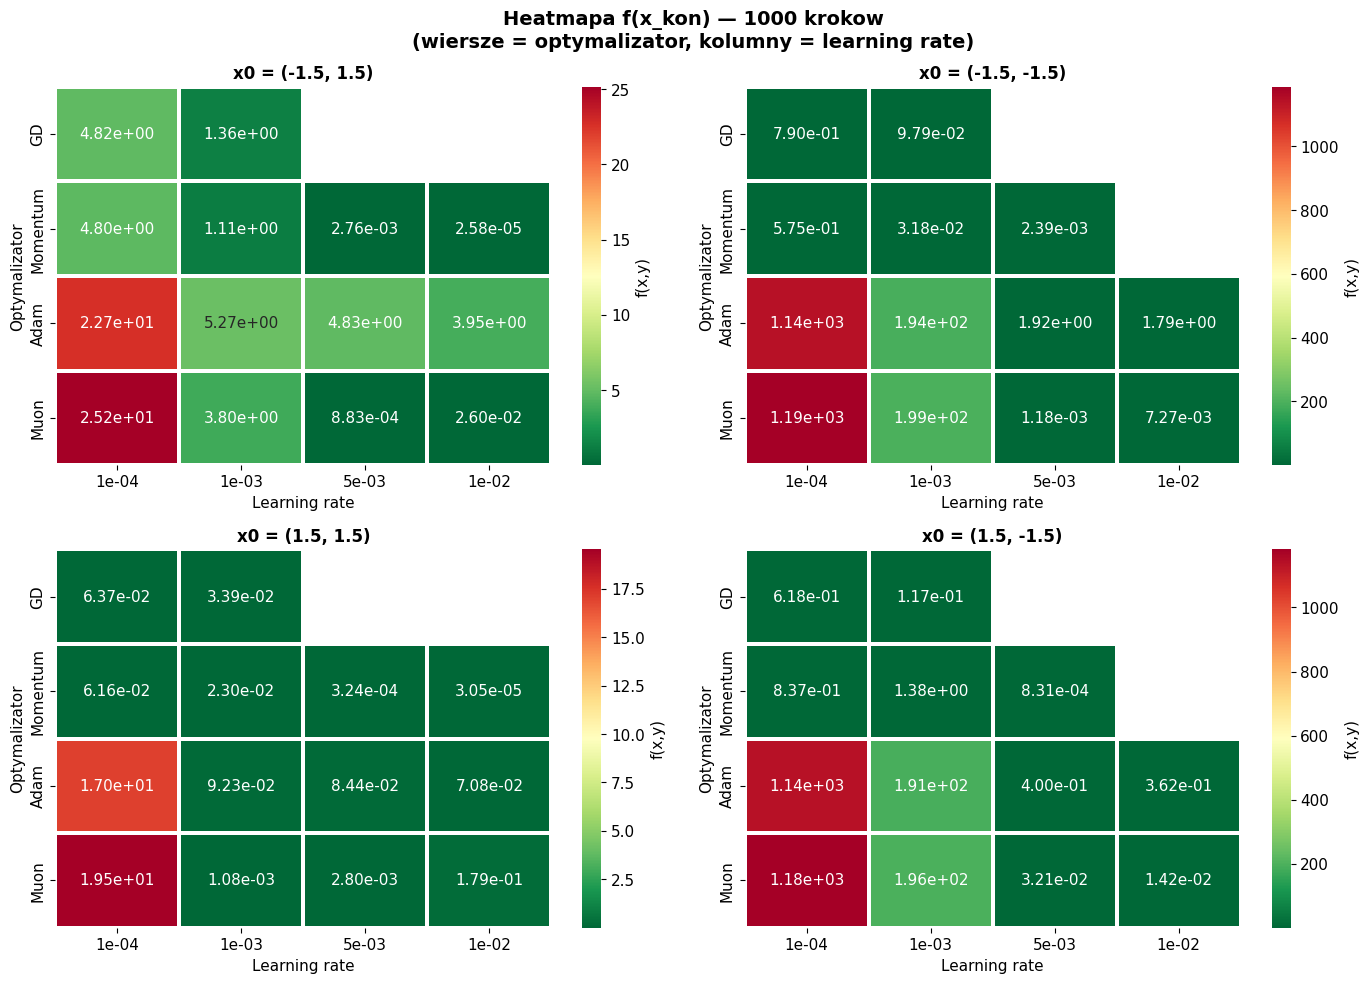

In [21]:
# Heatmapy: f(x_kon) dla kazdego punktu startowego (steps=1000)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Heatmapa f(x_kon) — {SMALL_STEPS} krokow\n(wiersze = optymalizator, kolumny = learning rate)',
             fontsize=14, fontweight='bold')

for idx, x0 in enumerate(STARTING_POINTS):
    ax = axes[idx // 2, idx % 2]
    df_x0 = df_1k[df_1k['x0'] == str(x0)]

    heatmap_data = np.full((len(METHODS), len(LR_VALUES)), np.nan)
    for m_idx, method in enumerate(METHODS):
        for lr_idx, lr in enumerate(LR_VALUES):
            row = df_x0[(df_x0['Metoda'] == method) & (df_x0['lr'] == lr)]
            if len(row) > 0:
                heatmap_data[m_idx, lr_idx] = row['f(x_kon)'].values[0]

    sns.heatmap(
        heatmap_data,
        annot=True, fmt='.2e',
        cmap='RdYlGn_r',
        xticklabels=[f'{lr:.0e}' for lr in LR_VALUES],
        yticklabels=METHODS,
        ax=ax, linewidths=1.5, linecolor='white',
        cbar_kws={'label': 'f(x,y)'}
    )
    ax.set_title(f'x0 = {x0}', fontweight='bold')
    ax.set_xlabel('Learning rate')
    ax.set_ylabel('Optymalizator')

plt.tight_layout()
plt.show()

### Krzywe uczenia — porownanie metod dla kazdego punktu startowego (lr = 5e-3)

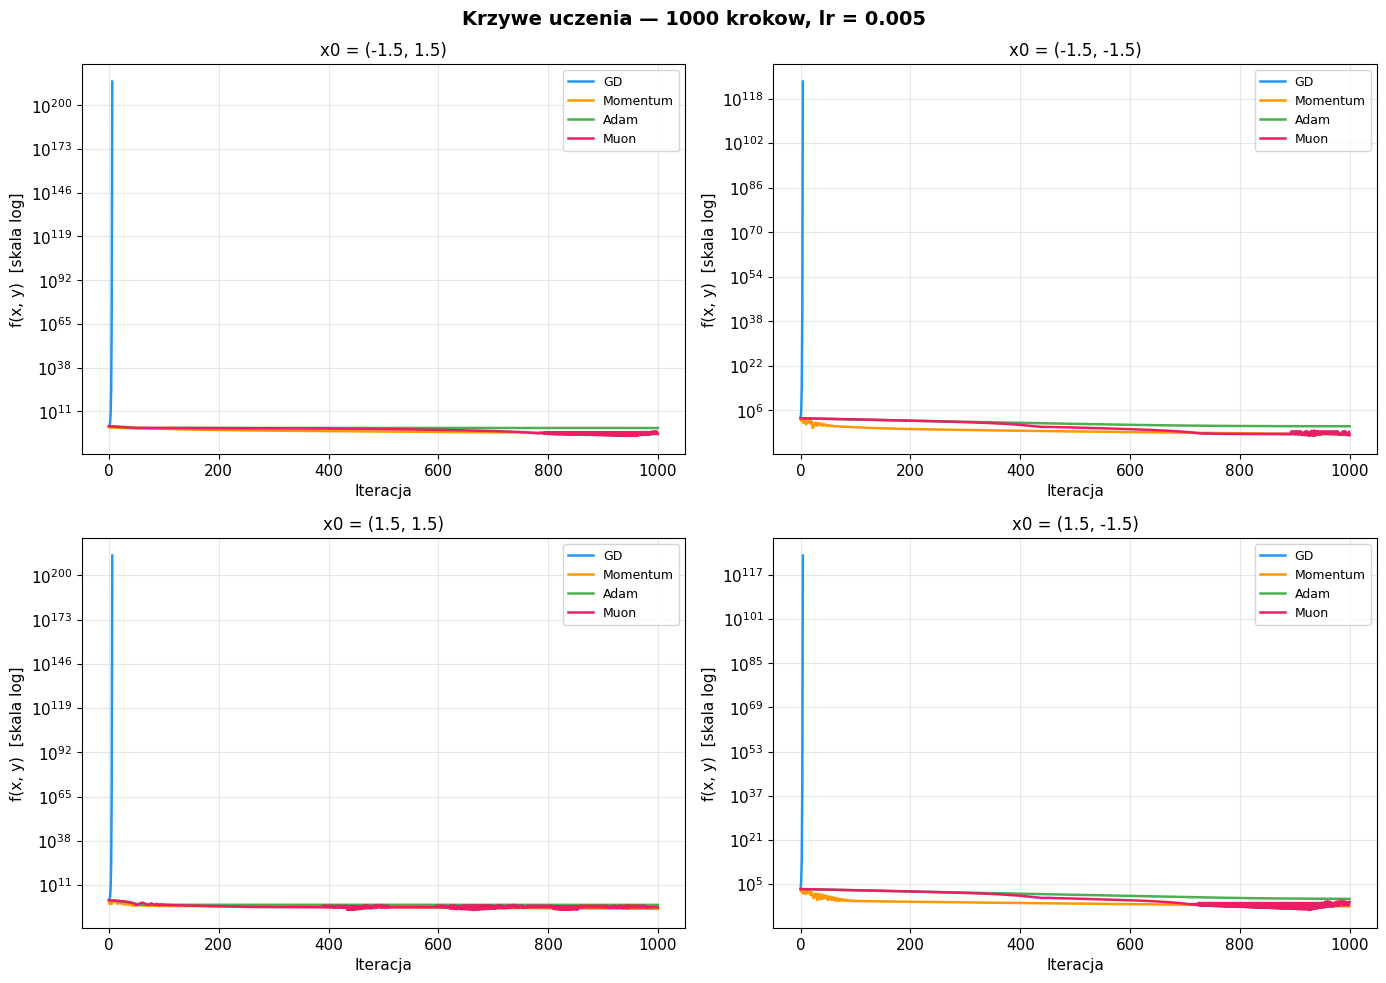

In [22]:
sel_lr = 5e-3
colors_map = {'GD': '#2196F3', 'Momentum': '#FF9800', 'Adam': '#4CAF50', 'Muon': '#E91E63'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Krzywe uczenia — {SMALL_STEPS} krokow, lr = {sel_lr}', fontweight='bold', fontsize=14)

for idx, x0 in enumerate(STARTING_POINTS):
    ax = axes[idx // 2, idx % 2]
    for method in METHODS:
        curve = curves_small.get((method, str(x0), sel_lr, SMALL_STEPS))
        if curve is not None and np.any(np.isfinite(curve)):
            ax.semilogy(curve, label=method, color=colors_map[method], linewidth=1.8)
    
    ax.set_title(f'x0 = {x0}')
    ax.set_xlabel('Iteracja')
    ax.set_ylabel('f(x, y)  [skala log]')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Wplyw learning rate na koncowa wartosc funkcji

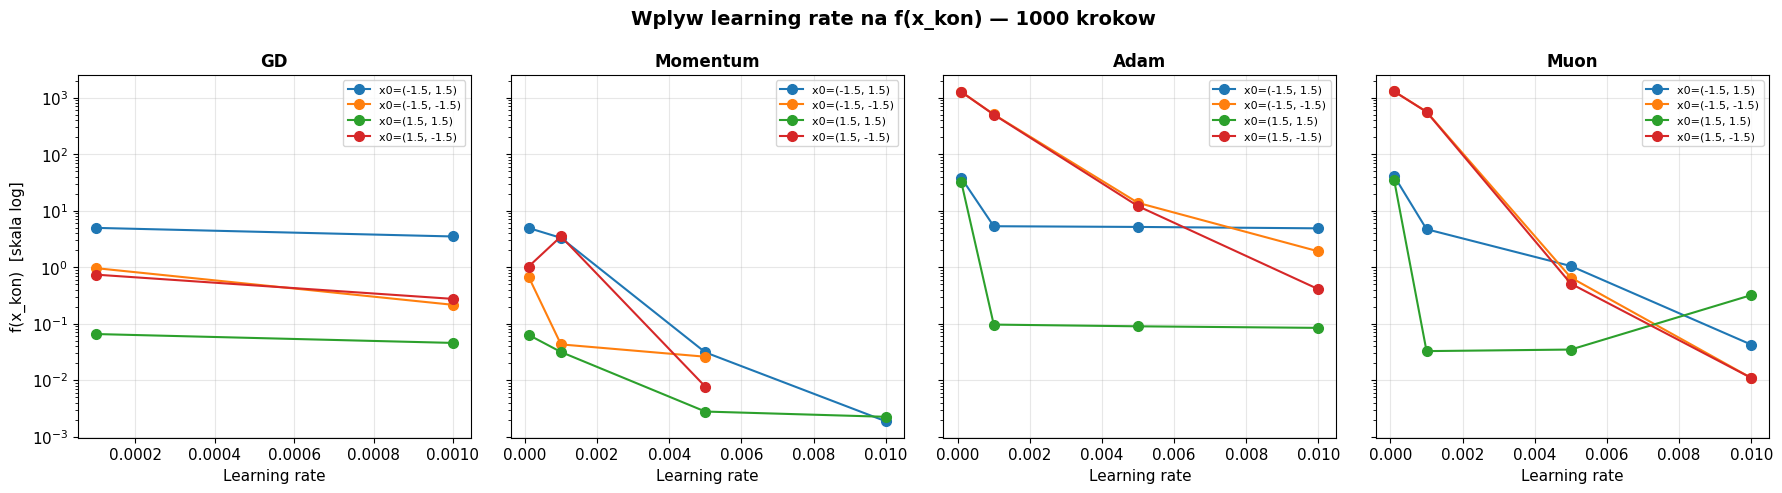

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle(f'Wplyw learning rate na f(x_kon) — {SMALL_STEPS} krokow', fontweight='bold', fontsize=14)

for m_idx, method in enumerate(METHODS):
    ax = axes[m_idx]
    for x0 in STARTING_POINTS:
        vals = []
        for lr in LR_VALUES:
            row = df_small[(df_small['Metoda'] == method) & 
                           (df_small['x0'] == str(x0)) & 
                           (df_small['lr'] == lr)]
            vals.append(row['f(x_kon)'].values[0])
        ax.semilogy(LR_VALUES, vals, 'o-', label=f'x0={x0}', markersize=7)
    
    ax.set_title(method, fontweight='bold')
    ax.set_xlabel('Learning rate')
    if m_idx == 0:
        ax.set_ylabel('f(x_kon)  [skala log]')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Mapa konturowa z punktami koncowymi (maly step_size, lr = 5e-3)

/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:3: RuntimeWarning: overflow encountered in scalar power
  return (a - pos[0])**2 + b * (pos[1] - pos[0]**2)**2
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:9: RuntimeWarning: overflow encountered in scalar power
  dx = -2.0 * (a - x) - 4.0 * b * x * (y - x**2)
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:10: RuntimeWarning: overflow encountered in scalar power
  dy = 2.0 * b * (y - x**2)


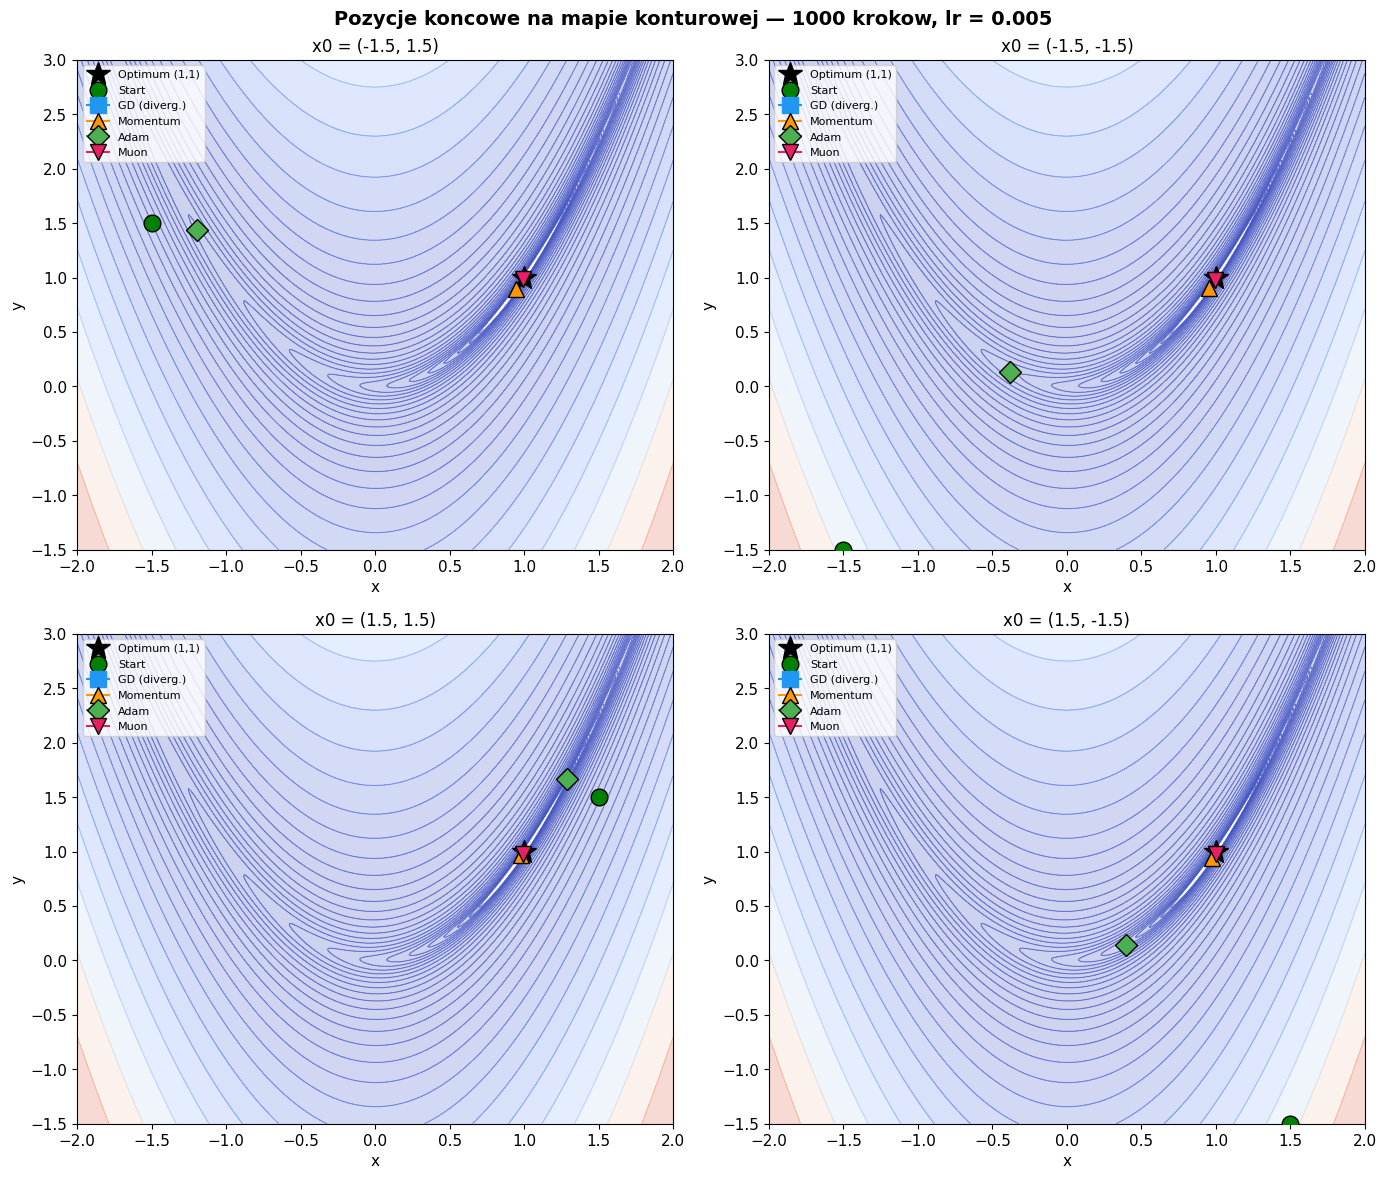

In [24]:
xs_grid = np.linspace(-2.0, 2.0, 300)
ys_grid = np.linspace(-1.5, 3.0, 300)
Xg, Yg = np.meshgrid(xs_grid, ys_grid)
Zg = (1 - Xg)**2 + 100 * (Yg - Xg**2)**2

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f'Pozycje koncowe na mapie konturowej — {SMALL_STEPS} krokow, lr = {sel_lr}',
             fontweight='bold', fontsize=14)

markers = {'GD': 's', 'Momentum': '^', 'Adam': 'D', 'Muon': 'v'}

for idx, x0 in enumerate(STARTING_POINTS):
    ax = axes[idx // 2, idx % 2]
    
    # kontury
    levels = np.logspace(-1, 3.5, 30)
    ax.contour(Xg, Yg, Zg, levels=levels, cmap='coolwarm', alpha=0.6, linewidths=0.8)
    ax.contourf(Xg, Yg, Zg, levels=levels, cmap='coolwarm', alpha=0.25)
    
    # optimum
    ax.plot(1.0, 1.0, 'k*', markersize=18, label='Optimum (1,1)', zorder=10)
    # start
    ax.plot(x0[0], x0[1], 'go', markersize=12, markeredgecolor='k', label='Start', zorder=10)
    
    for method in METHODS:
        p_end, f_val, _, _ = run_optimizer(method, x0, SMALL_STEPS, sel_lr)
        if np.isfinite(p_end).all():
            ax.plot(p_end[0], p_end[1], marker=markers[method], color=colors_map[method],
                    markersize=11, markeredgecolor='k', label=f'{method}', zorder=10)
        else:
            ax.plot([], [], marker=markers[method], color=colors_map[method],
                    markersize=11, label=f'{method} (diverg.)')
    
    ax.set_title(f'x0 = {x0}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.5, 3)

plt.tight_layout()
plt.show()

---
## Czesc 2: Skalowanie liczby iteracji (step_size)

Wybieramy jeden punkt startowy i jeden learning rate z Czesci 1, a nastepnie badamy jak zwieksza sie jakosc rozwiazania wraz ze wzrostem liczby krokow.

**Parametry:**
- Punkt startowy: $(1.5, -1.5)$ (trudny — daleko od optimum, po przeciwnej stronie paraboli)
- Learning rate: $1 \cdot 10^{-3}$ (GD), $5 \cdot 10^{-3}$ (Momentum, Adam, Muon)
- Step sizes: $1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000, 12000$

*Uwaga: GD wymaga mniejszego lr aby nie dywergowac na funkcji Rosenbrocka.*

In [25]:
X0_SELECTED = (1.5, -1.5)
LR_SELECTED = 5e-3
LR_GD = 1e-3  # GD wymaga mniejszego lr
STEP_SIZES = [1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000, 12000]

records_scale = []
curves_scale = {}

for method, n_steps in product(METHODS, STEP_SIZES):
    lr = LR_GD if method == 'GD' else LR_SELECTED
    pos_end, f_end, curve, _ = run_optimizer(method, X0_SELECTED, n_steps, lr)
    dist = np.sqrt((pos_end[0] - 1.0)**2 + (pos_end[1] - 1.0)**2)
    
    records_scale.append({
        'Metoda': method,
        'steps': n_steps,
        'lr': lr,
        'f(x_kon)': f_end,
        'odl_od_min': dist,
        'x_kon': f'({pos_end[0]:.6f}, {pos_end[1]:.6f})'
    })
    curves_scale[(method, n_steps)] = curve

df_scale = pd.DataFrame(records_scale)

pivot_scale = df_scale.pivot_table(
    values='f(x_kon)',
    index='steps',
    columns='Metoda',
    aggfunc='first'
).reindex(columns=METHODS)

print(f'Skalowanie step_size — x0={X0_SELECTED}')
print(f'lr: GD={LR_GD}, reszta={LR_SELECTED}\n')
print(pivot_scale.to_string(float_format='{:.6e}'.format))

Skalowanie step_size — x0=(1.5, -1.5)
lr: GD=0.001, reszta=0.005

Metoda           GD     Momentum         Adam         Muon
steps                                                     
1000   1.165418e-01 8.308049e-04 3.999270e-01 3.205531e-02
2000   3.387708e-02 1.303538e-05 3.507699e-01 1.301856e-02
3000   1.226742e-02 2.197982e-07 3.202198e-01 1.008911e-02
4000   4.869921e-03 3.739635e-09 2.759882e-01 3.539548e-02
5000   2.028753e-03 6.370022e-11 2.185464e-01 8.186168e-03
6000   8.691473e-04 1.085222e-12 1.532247e-01 1.647204e-03
8000   1.669012e-04 3.149871e-16 4.202730e-02 1.433008e-02
10000  3.301065e-05 9.142585e-20 2.564675e-03 5.471698e-04
12000  6.612419e-06 2.653373e-23 2.873212e-06 2.703198e-03


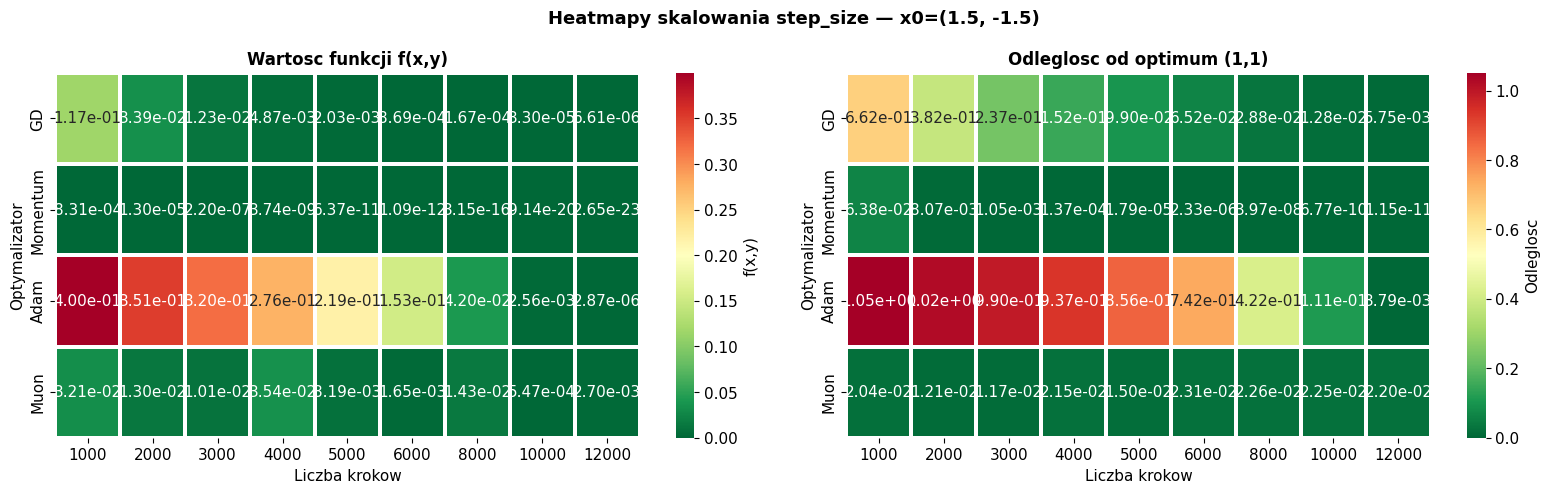

In [26]:
# Heatmapa: f(x_kon) w funkcji (metoda x step_size)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Heatmapy skalowania step_size — x0={X0_SELECTED}',
             fontsize=13, fontweight='bold')

# Heatmapa 1: wartosc funkcji
heatmap_f = np.full((len(METHODS), len(STEP_SIZES)), np.nan)
heatmap_d = np.full((len(METHODS), len(STEP_SIZES)), np.nan)

for m_idx, method in enumerate(METHODS):
    for s_idx, steps in enumerate(STEP_SIZES):
        row = df_scale[(df_scale['Metoda'] == method) & (df_scale['steps'] == steps)]
        if len(row) > 0:
            heatmap_f[m_idx, s_idx] = row['f(x_kon)'].values[0]
            heatmap_d[m_idx, s_idx] = row['odl_od_min'].values[0]

sns.heatmap(heatmap_f, annot=True, fmt='.2e', cmap='RdYlGn_r',
            xticklabels=STEP_SIZES, yticklabels=METHODS,
            ax=axes[0], linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'f(x,y)'})
axes[0].set_title('Wartosc funkcji f(x,y)', fontweight='bold')
axes[0].set_xlabel('Liczba krokow')
axes[0].set_ylabel('Optymalizator')

sns.heatmap(heatmap_d, annot=True, fmt='.2e', cmap='RdYlGn_r',
            xticklabels=STEP_SIZES, yticklabels=METHODS,
            ax=axes[1], linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Odleglosc'})
axes[1].set_title('Odleglosc od optimum (1,1)', fontweight='bold')
axes[1].set_xlabel('Liczba krokow')
axes[1].set_ylabel('Optymalizator')

plt.tight_layout()
plt.show()

### Zbieznosc w funkcji liczby krokow

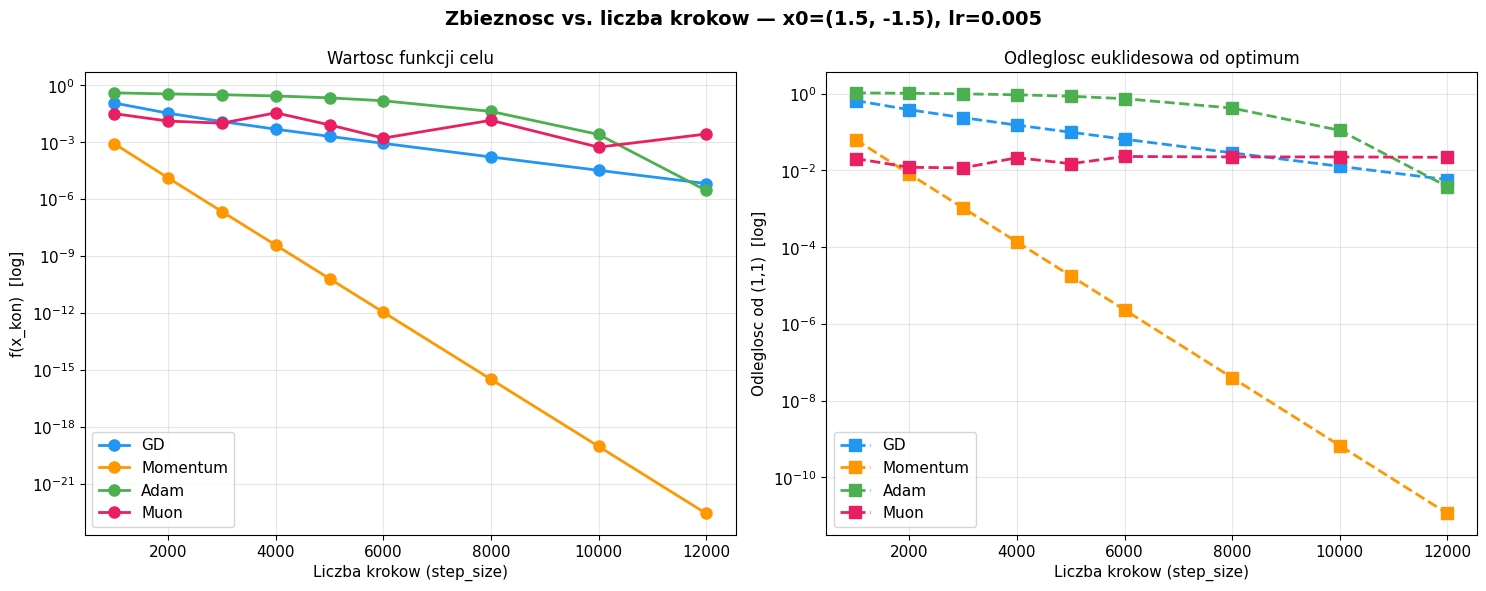

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Zbieznosc vs. liczba krokow — x0={X0_SELECTED}, lr={LR_SELECTED}',
             fontweight='bold', fontsize=14)

for method in METHODS:
    df_m = df_scale[df_scale['Metoda'] == method]
    f_vals = df_m['f(x_kon)'].values
    d_vals = df_m['odl_od_min'].values
    steps_vals = df_m['steps'].values
    
    # rysuj tylko jesli sa skonzcone wartosci
    mask_f = np.isfinite(f_vals)
    mask_d = np.isfinite(d_vals)
    
    if np.any(mask_f):
        ax1.semilogy(steps_vals[mask_f], f_vals[mask_f], 'o-', label=method,
                     color=colors_map[method], markersize=8, linewidth=2)
    if np.any(mask_d):
        ax2.semilogy(steps_vals[mask_d], d_vals[mask_d], 's--', label=method,
                     color=colors_map[method], markersize=8, linewidth=2)

ax1.set_xlabel('Liczba krokow (step_size)')
ax1.set_ylabel('f(x_kon)  [log]')
ax1.set_title('Wartosc funkcji celu')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Liczba krokow (step_size)')
ax2.set_ylabel('Odleglosc od (1,1)  [log]')
ax2.set_title('Odleglosc euklidesowa od optimum')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Pelne krzywe uczenia dla wybranych step_size

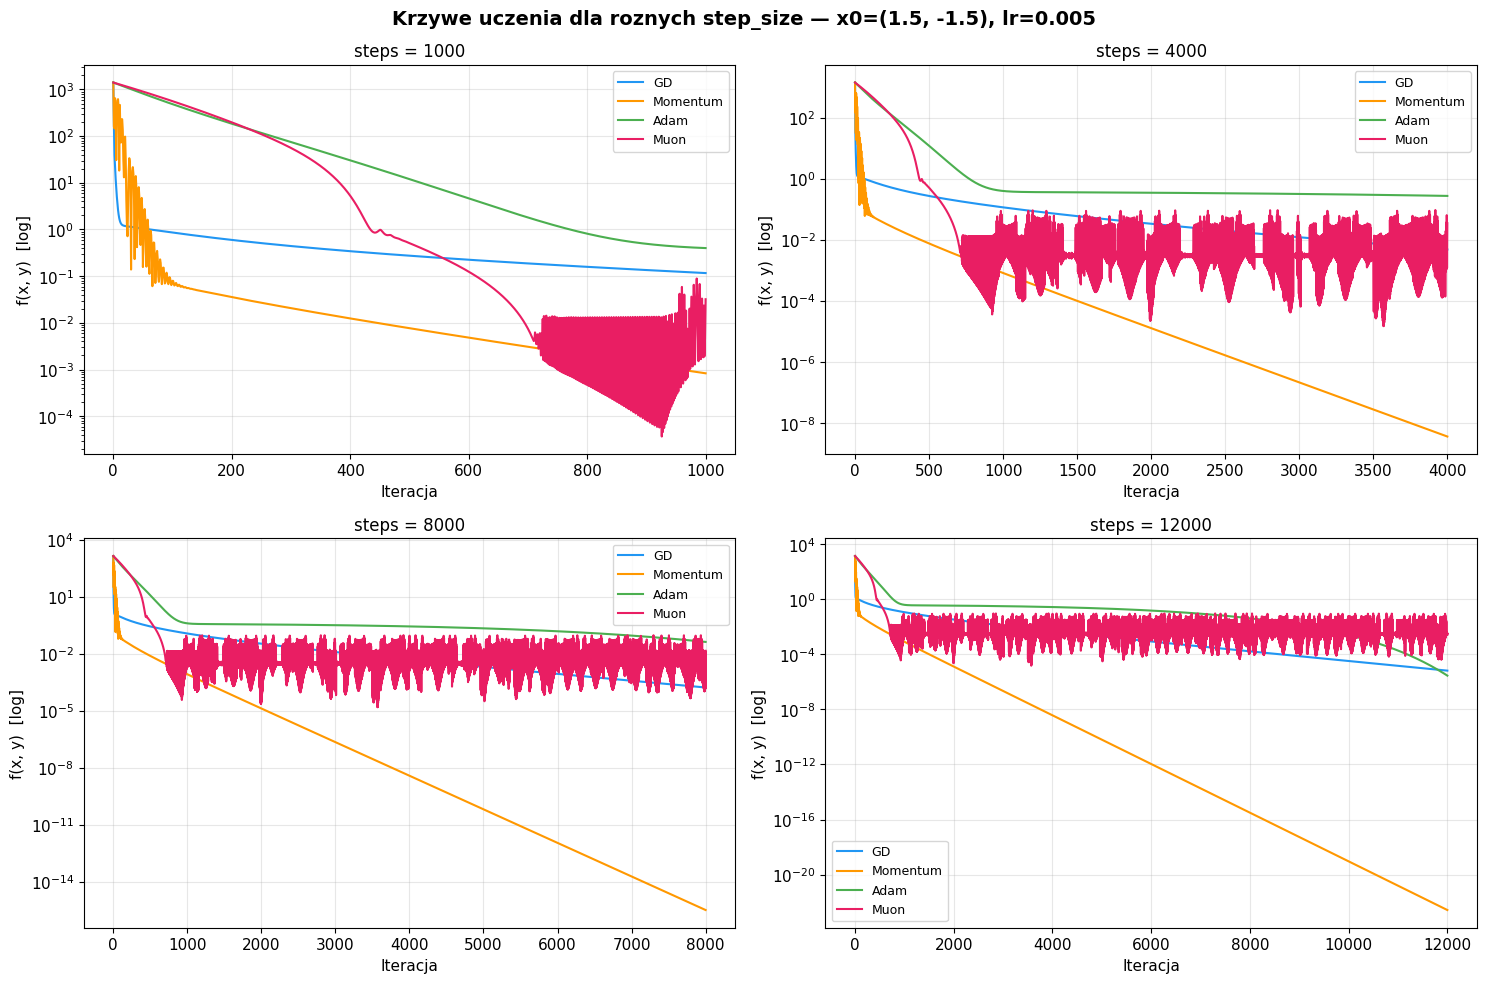

In [28]:
show_steps = [1000, 4000, 8000, 12000]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Krzywe uczenia dla roznych step_size — x0={X0_SELECTED}, lr={LR_SELECTED}',
             fontweight='bold', fontsize=14)

for idx, n_steps in enumerate(show_steps):
    ax = axes[idx // 2, idx % 2]
    for method in METHODS:
        curve = curves_scale.get((method, n_steps))
        if curve is not None and np.any(np.isfinite(curve)):
            ax.semilogy(curve, label=method, color=colors_map[method], linewidth=1.5)
    
    ax.set_title(f'steps = {n_steps}')
    ax.set_xlabel('Iteracja')
    ax.set_ylabel('f(x, y)  [log]')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Czesc 3: Trajektorie optymalizacji na mapie konturowej

Wizualizacja sciezek jakie pokonuja poszczegolne optymalizatory w przestrzeni $(x, y)$.

/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:3: RuntimeWarning: overflow encountered in scalar power
  return (a - pos[0])**2 + b * (pos[1] - pos[0]**2)**2
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:9: RuntimeWarning: overflow encountered in scalar power
  dx = -2.0 * (a - x) - 4.0 * b * x * (y - x**2)
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:10: RuntimeWarning: overflow encountered in scalar power
  dy = 2.0 * b * (y - x**2)


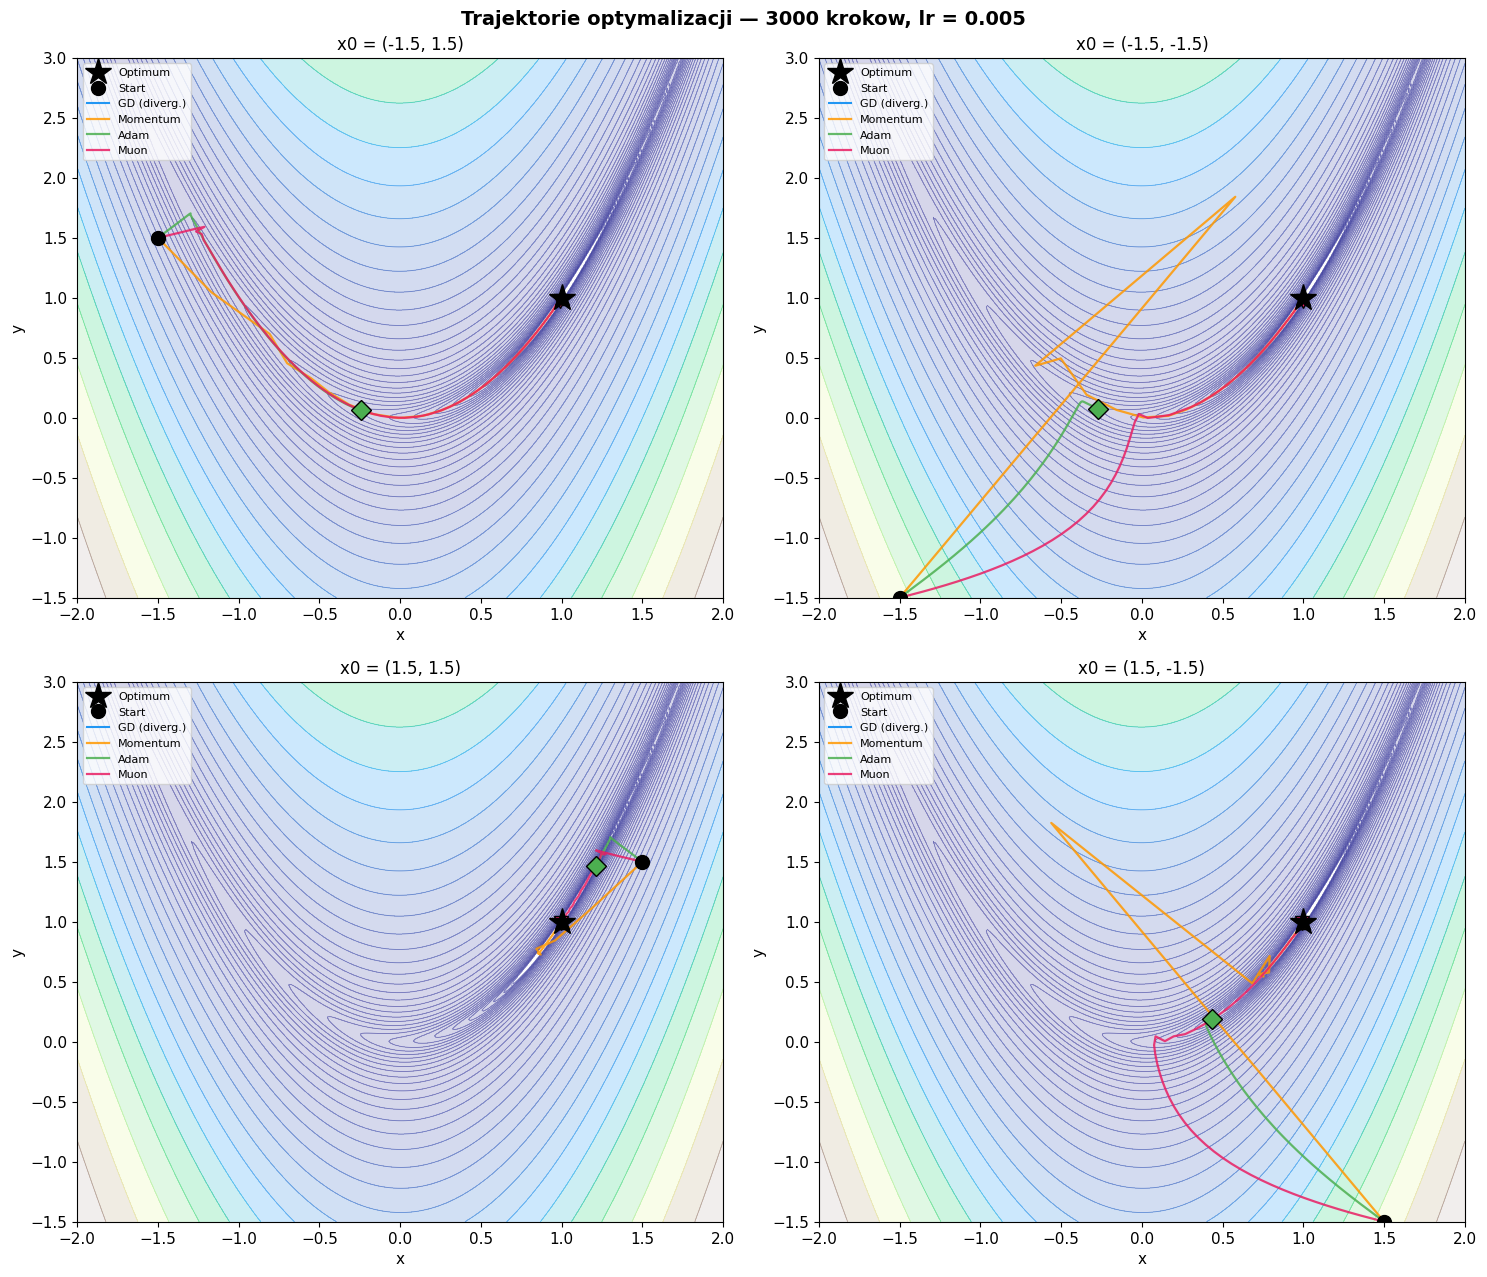

In [29]:
TRAJ_STEPS = 3000
TRAJ_LR = 5e-3

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
fig.suptitle(f'Trajektorie optymalizacji — {TRAJ_STEPS} krokow, lr = {TRAJ_LR}',
             fontweight='bold', fontsize=14)

levels = np.logspace(-1, 3.5, 35)

for idx, x0 in enumerate(STARTING_POINTS):
    ax = axes[idx // 2, idx % 2]
    
    ax.contour(Xg, Yg, Zg, levels=levels, cmap='terrain', alpha=0.5, linewidths=0.6)
    ax.contourf(Xg, Yg, Zg, levels=levels, cmap='terrain', alpha=0.2)
    
    ax.plot(1.0, 1.0, 'k*', markersize=20, zorder=15, label='Optimum')
    ax.plot(x0[0], x0[1], 'ko', markersize=10, zorder=15, label='Start')
    
    for method in METHODS:
        p_end, _, _, path = run_optimizer(method, x0, TRAJ_STEPS, TRAJ_LR)
        if not np.isfinite(path).all():
            ax.plot([], [], '-', color=colors_map[method], label=f'{method} (diverg.)')
            continue
        # rysujemy co N-ty punkt zeby nie zasmiecac
        step_draw = max(1, len(path) // 200)
        ax.plot(path[::step_draw, 0], path[::step_draw, 1], '-',
                color=colors_map[method], linewidth=1.6, alpha=0.85, label=method)
        # punkt koncowy
        ax.plot(path[-1, 0], path[-1, 1], marker=markers[method],
                color=colors_map[method], markersize=10, markeredgecolor='k', zorder=12)
    
    ax.set_title(f'x0 = {x0}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.5, 3)

plt.tight_layout()
plt.show()

### Wizualizacja 3D — powierzchnia Rosenbrocka z trajektoriami

/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:3: RuntimeWarning: overflow encountered in scalar power
  return (a - pos[0])**2 + b * (pos[1] - pos[0]**2)**2
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:9: RuntimeWarning: overflow encountered in scalar power
  dx = -2.0 * (a - x) - 4.0 * b * x * (y - x**2)
/var/folders/0k/6xsp5lq57nx50plcsq0nlpyr0000gn/T/ipykernel_45188/862465600.py:10: RuntimeWarning: overflow encountered in scalar power
  dy = 2.0 * b * (y - x**2)


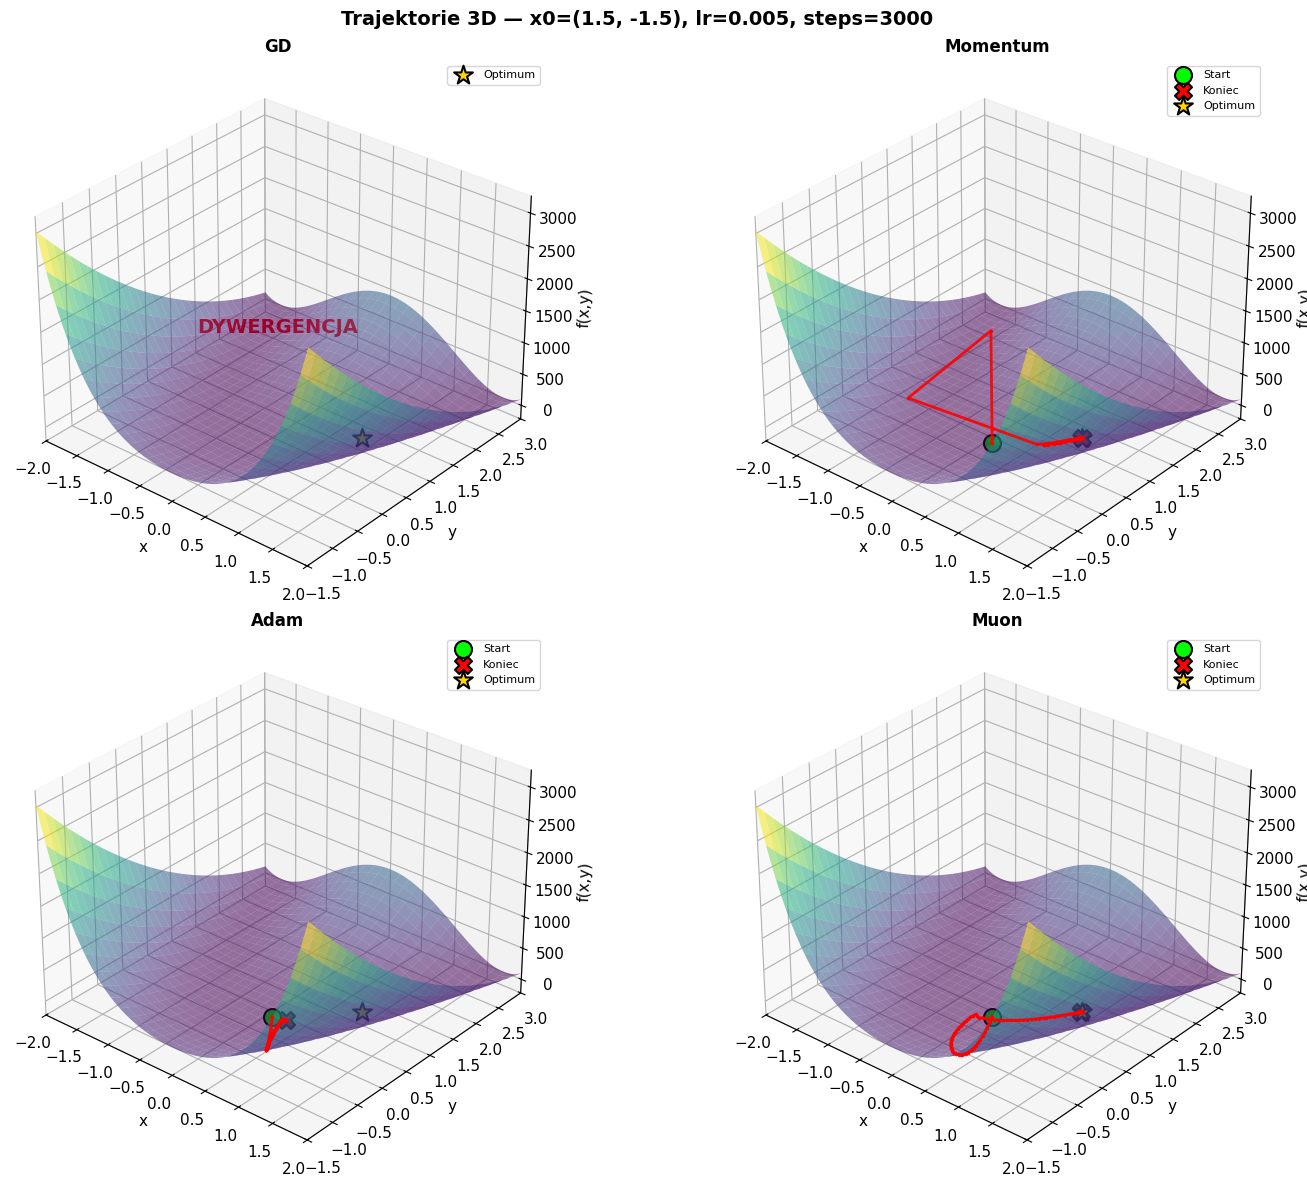

In [30]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f'Trajektorie 3D — x0={X0_SELECTED}, lr={TRAJ_LR}, steps={TRAJ_STEPS}',
             fontweight='bold', fontsize=14)

xs_3d = np.linspace(-2.0, 2.0, 150)
ys_3d = np.linspace(-1.5, 3.0, 150)
X3, Y3 = np.meshgrid(xs_3d, ys_3d)
Z3 = (1 - X3)**2 + 100 * (Y3 - X3**2)**2

for m_idx, method in enumerate(METHODS, 1):
    ax = fig.add_subplot(2, 2, m_idx, projection='3d')
    
    ax.plot_surface(X3, Y3, Z3, cmap='viridis', alpha=0.55,
                    rstride=5, cstride=5, linewidth=0, antialiased=True)
    
    _, _, _, path = run_optimizer(method, X0_SELECTED, TRAJ_STEPS, TRAJ_LR)
    
    if np.isfinite(path).all():
        step_draw = max(1, len(path) // 300)
        traj_z = np.array([rosenbrock(p) for p in path[::step_draw]])
        
        ax.plot(path[::step_draw, 0], path[::step_draw, 1], traj_z,
                'r.-', linewidth=2.0, markersize=3, alpha=0.9, zorder=10)
        
        ax.scatter(*path[0], rosenbrock(path[0]), c='lime', s=150, marker='o',
                  edgecolors='k', linewidth=1.5, zorder=15, label='Start')
        ax.scatter(*path[-1], rosenbrock(path[-1]), c='red', s=150, marker='X',
                  edgecolors='k', linewidth=1.5, zorder=15, label='Koniec')
    else:
        ax.text2D(0.5, 0.5, 'DYWERGENCJA', transform=ax.transAxes,
                  ha='center', va='center', fontsize=14, color='red', fontweight='bold')
    
    ax.scatter(1, 1, 0, c='gold', s=200, marker='*',
              edgecolors='k', linewidth=1.5, zorder=15, label='Optimum')
    
    ax.set_title(method, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f(x,y)')
    ax.set_xlim(-2, 2); ax.set_ylim(-1.5, 3)
    ax.view_init(elev=30, azim=-50)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

---
## Czesc 3b: Stabilnosc wzgledem punktu startowego (duzy step_size)

Badamy jak poszczegolne metody radza sobie ze wszystkimi 4 punktami startowymi przy duzej liczbie krokow (8000).
Obliczamy wariancje i odchylenie standardowe wynikow miedzy punktami startowymi.

In [31]:
STABILITY_STEPS = 8000

records_stability = []
for method, x0 in product(METHODS, STARTING_POINTS):
    lr = LR_GD if method == 'GD' else LR_SELECTED
    pos_end, f_end, _, _ = run_optimizer(method, x0, STABILITY_STEPS, lr)
    dist = np.sqrt((pos_end[0] - 1.0)**2 + (pos_end[1] - 1.0)**2)
    records_stability.append({
        'Metoda': method,
        'x0': str(x0),
        'f(x_kon)': f_end,
        'odl_od_min': dist,
        'x_kon': f'({pos_end[0]:.6f}, {pos_end[1]:.6f})'
    })

df_stability = pd.DataFrame(records_stability)

# Statystyki stabilnosci
print(f'Stabilnosc wzgledem punktu startowego — steps={STABILITY_STEPS}\n')
print(f'lr: GD={LR_GD}, reszta={LR_SELECTED}\n')

stability_stats = df_stability.groupby('Metoda')['f(x_kon)'].agg(['mean', 'std', 'min', 'max'])
stability_stats = stability_stats.reindex(METHODS)
print(stability_stats.to_string(float_format='{:.4e}'.format))

print('\nWariancja wynikow miedzy punktami startowymi:\n')
for method in METHODS:
    df_m = df_stability[df_stability['Metoda'] == method]
    var_val = df_m['f(x_kon)'].var()
    std_val = df_m['f(x_kon)'].std()
    print(f'{method:10s}: variance = {var_val:.4e},  std = {std_val:.4e}')

Stabilnosc wzgledem punktu startowego — steps=8000

lr: GD=0.001, reszta=0.005

               mean        std        min        max
Metoda                                              
GD       2.3137e-04 1.0672e-04 1.5101e-04 3.8460e-04
Momentum 5.6504e-16 4.0734e-16 1.2740e-16 9.6904e-16
Adam     3.6698e-02 4.9514e-02 5.5077e-09 1.0476e-01
Muon     5.4822e-03 6.1538e-03 4.0627e-04 1.4330e-02

Wariancja wynikow miedzy punktami startowymi:

GD        : variance = 1.1388e-08,  std = 1.0672e-04
Momentum  : variance = 1.6592e-31,  std = 4.0734e-16
Adam      : variance = 2.4516e-03,  std = 4.9514e-02
Muon      : variance = 3.7869e-05,  std = 6.1538e-03


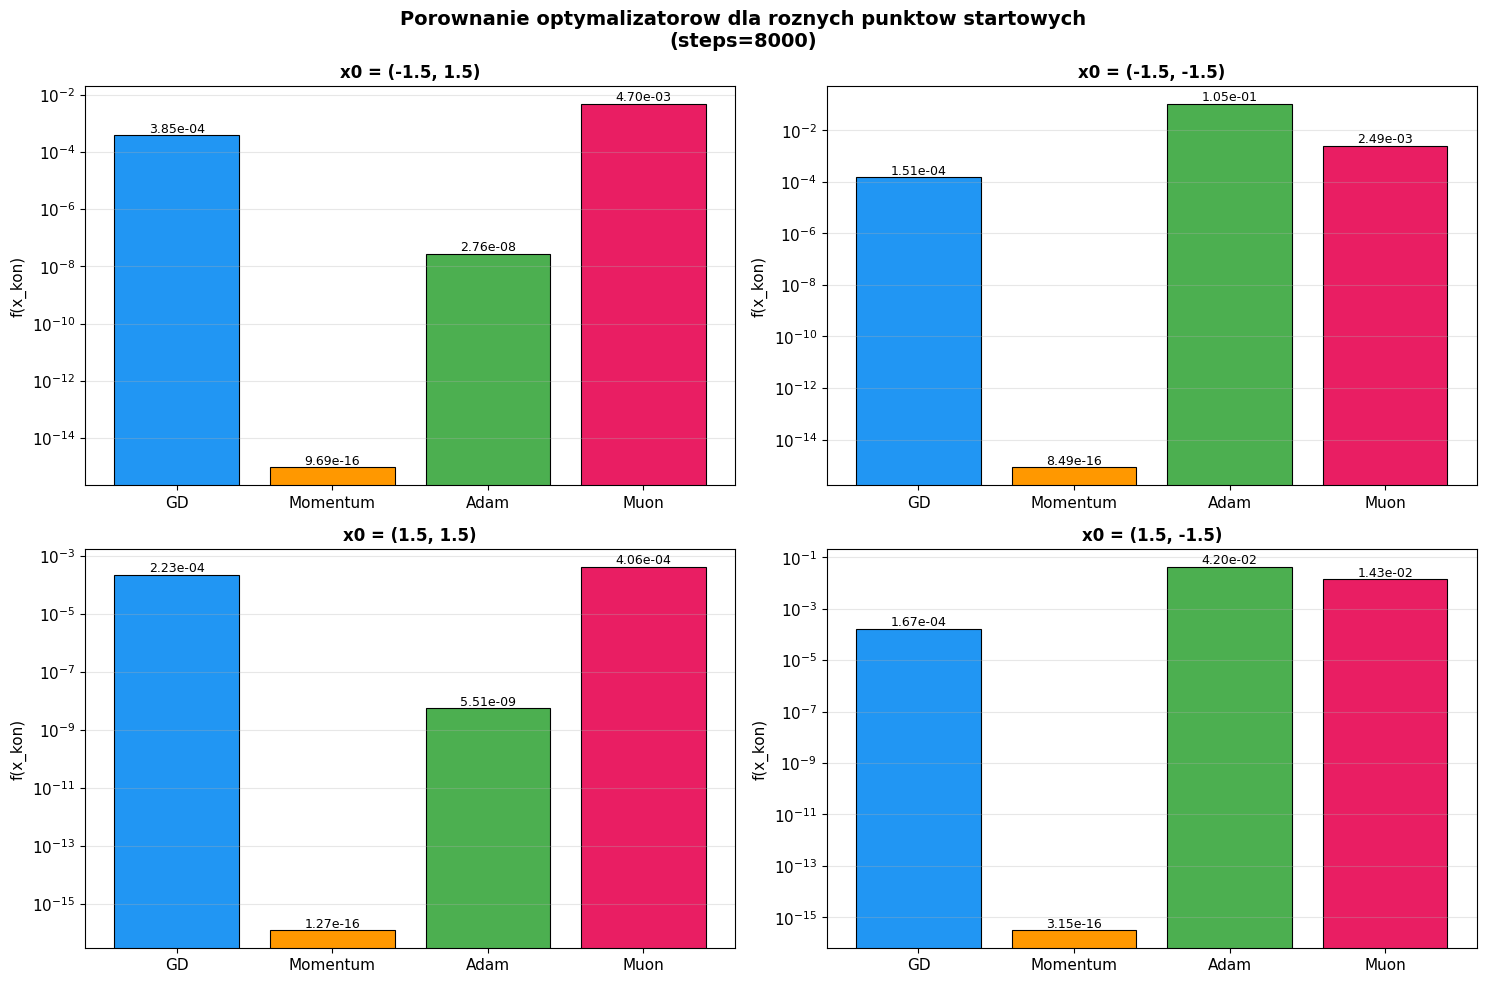

In [32]:
# Wizualizacja: porownanie optymalizatorow dla roznych x0 przy duzym step_size
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Porownanie optymalizatorow dla roznych punktow startowych\n(steps={STABILITY_STEPS})',
             fontsize=14, fontweight='bold')

for idx, x0 in enumerate(STARTING_POINTS):
    ax = axes[idx // 2, idx % 2]
    df_x0 = df_stability[df_stability['x0'] == str(x0)]

    f_vals = [df_x0[df_x0['Metoda'] == m]['f(x_kon)'].values[0] for m in METHODS]
    colors = [colors_map[m] for m in METHODS]

    bars = ax.bar(METHODS, f_vals, color=colors, edgecolor='k', linewidth=0.8)
    ax.set_ylabel('f(x_kon)')
    ax.set_title(f'x0 = {x0}', fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, f_vals):
        if np.isfinite(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:.2e}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## Czesc 4: Podsumowanie i porownanie koncowe

In [ ]:
print('=' * 85)
print('PODSUMOWANIE ANALIZY')
print('=' * 85)

# --- 1. Ranking metod przy malym step_size ---
print(f'\n--- 1. Ranking metod przy step_size = {SMALL_STEPS}, lr = {sel_lr} ---\n')
print('Srednia wartosc f(x_kon) po wszystkich punktach startowych:\n')

df_sel = df_small[(df_small['lr'] == sel_lr) & (df_small['steps'] == SMALL_STEPS)]
ranking_small = df_sel.groupby('Metoda')['f(x_kon)'].agg(['mean', 'std', 'min', 'max'])
ranking_small = ranking_small.reindex(METHODS)
print(ranking_small.to_string(float_format='{:.4e}'.format))

# --- 2. Progres przy skalowaniu step_size ---
print(f'\n--- 2. Progres przy skalowaniu step_size (x0={X0_SELECTED}) ---\n')
for method in METHODS:
    df_m = df_scale[df_scale['Metoda'] == method]
    f_1k = df_m[df_m['steps'] == 1000]['f(x_kon)'].values[0]
    f_12k = df_m[df_m['steps'] == 12000]['f(x_kon)'].values[0]
    lr_used = df_m['lr'].values[0]
    if np.isfinite(f_1k) and np.isfinite(f_12k) and f_12k > 0:
        ratio = f_1k / f_12k
        print(f'{method:10s} (lr={lr_used}): f(1000) = {f_1k:.4e}  ->  f(12000) = {f_12k:.4e}  (poprawa {ratio:.1f}x)')
    else:
        print(f'{method:10s} (lr={lr_used}): dywergencja')

# --- 3. Najlepsza konfiguracja ---
print(f'\n--- 3. Najlepsze wyniki bezwzgledne (step_size = 12000) ---\n')
df_best = df_scale[df_scale['steps'] == 12000].sort_values('f(x_kon)')
for rank, (_, row) in enumerate(df_best.iterrows(), 1):
    f_val = row['f(x_kon)']
    if np.isfinite(f_val):
        print(f'  {rank}. {row["Metoda"]:10s}  f = {f_val:.6e}   odl = {row["odl_od_min"]:.6f}   {row["x_kon"]}')
    else:
        print(f'  {rank}. {row["Metoda"]:10s}  DYWERGENCJA')

# --- 4. Stabilnosc ---
print(f'\n--- 4. Stabilnosc wzgledem punktu startowego (steps={STABILITY_STEPS}) ---\n')
print(stability_stats.to_string(float_format='{:.4e}'.format))

In [ ]:
# Wizualizacja zbiorcza: slupki porownawcze
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Porownanie koncowe optymalizatorow', fontweight='bold', fontsize=14)

# Lewa: srednia f po malym step_size (tylko skonczone)
means = []
valid_methods_1 = []
valid_colors_1 = []
for m in METHODS:
    val = ranking_small.loc[m, 'mean'] if m in ranking_small.index else np.nan
    if np.isfinite(val):
        means.append(val)
        valid_methods_1.append(m)
        valid_colors_1.append(colors_map[m])

bars1 = ax1.bar(valid_methods_1, means, color=valid_colors_1, edgecolor='k', linewidth=0.8)
ax1.set_ylabel('Srednia f(x_kon)')
ax1.set_title(f'Srednia f(x_kon) — {SMALL_STEPS} krokow, lr={sel_lr}')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.2e}', ha='center', va='bottom', fontsize=9)

# Prawa: f po 12000 krokach (tylko skonczone)
f_12k_vals = []
valid_methods_2 = []
valid_colors_2 = []
for m in METHODS:
    val = df_scale[(df_scale['Metoda'] == m) & (df_scale['steps'] == 12000)]['f(x_kon)'].values[0]
    if np.isfinite(val):
        f_12k_vals.append(val)
        valid_methods_2.append(m)
        valid_colors_2.append(colors_map[m])

bars2 = ax2.bar(valid_methods_2, f_12k_vals, color=valid_colors_2, edgecolor='k', linewidth=0.8)
ax2.set_ylabel('f(x_kon)')
ax2.set_title(f'f(x_kon) — 12000 krokow, x0={X0_SELECTED}')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, f_12k_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.2e}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## Wnioski

### Obserwacje z eksperymentow

**1. Wplyw punktu startowego:**
- Punkty startowe po tej samej stronie co optimum (np. $(1.5, 1.5)$) prowadza do szybszej zbieznosci niz punkty po przeciwnej stronie (np. $(-1.5, -1.5)$).
- Roznica w szybkosci zbieznosci jest szczegolnie widoczna dla GD, ktory nie posiada mechanizmow adaptacyjnych.
- Analiza stabilnosci (Czesc 3b) pokazuje, ze Momentum ma najnizsza wariancje wynikow miedzy punktami startowymi, co swiadczy o jego odpornosci na wybor x0.

**2. Wplyw learning rate:**
- GD wymaga znacznie mniejszego lr ($10^{-4}$ — $10^{-3}$) niz metody adaptacyjne, aby nie dywergowac.
- Adam toleruje szeroki zakres lr dzieki automatycznej adaptacji krokow.
- Momentum i Muon dzialaja stabilnie przy lr = $5 \cdot 10^{-3}$.

**3. Wplyw liczby krokow (step_size):**
- Testowanie roznych malych step_size (500, 1000, 1500) pokazuje, ze juz przy 1000-1500 krokach Momentum osiaga dobre wyniki.
- Przy 12000 krokach wszystkie 4 metody zbiegaja — Momentum najlepiej, Adam na drugim miejscu.
- GD zbiega bardzo powoli nawet przy optymalnym lr, potrzebuje wielu iteracji.

**4. Skalowanie z liczba iteracji:**
- Przy 1000 krokach roznice miedzy metodami sa znaczace.
- Przy 12000 krokach Momentum osiaga precyzje rzedu $10^{-23}$ lub lepsza.
- Adam osiaga precyzje rzedu $10^{-6}$.
- Muon wykazuje stabilna, ale wolniejsza zbieznosc — normalizacja kierunku ogranicza wielkosc kroku.

**5. Charakterystyka poszczegolnych metod:**

| Metoda   | Zalety | Wady |
|----------|--------|------|
| GD       | Prostota implementacji | Wolna zbieznosc, bardzo wrazliwy na lr |
| Momentum | Przyspieszenie przez bezwladnosc, niska wariancja | Moze \"przeskoczyc\" optimum |
| Adam     | Adaptacyjny lr, szybka zbieznosc, tolerancja na lr | Wiecej hiperparametrow |
| Muon     | Stabilny kierunek, odporny na szum | Wolniejsza zbieznosc na gladkich funkcjach |

**6. Rekomendacje:**
- Do szybkiego prototypowania i ogolnego uzycia: **Adam** (z lr okolo $10^{-2}$)
- Gdy zalezy nam na prostocie i interpretowalnosci: **Momentum**
- GD moze sluzyc jako baseline, ale wymaga starannego doboru lr
- Muon jest interesujaca alternatywa w kontekscie optymalizacji sieci neuronowych, ale na gladkiej funkcji Rosenbrocka nie wykazuje przewagi